# Tutorial on self-normalizing networks on the MNIST data set: convolutional neural networks

Originally by Kajetan Schweighofer (2021), adapted and refactored by Alexander Mair (2026).

In [1]:
import os

# Work around duplicate OpenMP runtimes when using recent pip PyTorch wheels
# inside a Conda environment on macOS.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("OMP_NUM_THREADS", "1")

import copy
import random
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from tqdm.auto import tqdm


def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(42)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: mps


In [2]:
# Load data and preprocess.
path = os.path.join(".", "dataset", "mnist")
os.makedirs(path, exist_ok=True)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train = torchvision.datasets.MNIST(path, download=True, train=True, transform=transform)
test = torchvision.datasets.MNIST(path, download=True, train=False, transform=transform)


## Functions

### Model

In [ ]:
class CNN(nn.Module):

    def __init__(self, out_features: int, p_drop: float = 0.2, use_selu: bool = False):
        super().__init__()

        activation = nn.SELU if use_selu else nn.ReLU
        dropout = nn.AlphaDropout if use_selu else nn.Dropout

        self.net = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=8, kernel_size=5),
            activation(),
            nn.MaxPool2d(kernel_size=2),
            
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3),
            activation(),
            nn.MaxPool2d(kernel_size=2),

            nn.Flatten(),
            nn.Linear(in_features=16 * 5 * 5, out_features=512),
            activation(),
            dropout(p=p_drop),

            nn.Linear(in_features=512, out_features=out_features),
        )

        if use_selu:
            self.reset_parameters_for_selu()

    def reset_parameters_for_selu(self):
        for module in self.modules():
            if isinstance(module, (nn.Conv2d, nn.Linear)):
                nn.init.kaiming_normal_(module.weight, mode="fan_in", nonlinearity="linear")
                nn.init.zeros_(module.bias)

    def forward(self, x):
        return self.net(x)


### Training / Evaluation methods

In [ ]:
def train_one_epoch(model: nn.Module, loader: DataLoader, loss_fn: nn.Module, optimizer: torch.optim.Optimizer, device: torch.device) -> list[float]:
    model.train()
    batch_losses = []

    for inputs, targets in loader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(inputs)
        loss = loss_fn(logits, targets)
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.detach().cpu().item())

    return batch_losses


@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, loss_fn: nn.Module, device: torch.device) -> tuple[float, float]:
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for inputs, targets in loader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        logits = model(inputs)
        loss = loss_fn(logits, targets)

        batch_size = targets.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == targets).sum().item()
        total_examples += batch_size

    return total_loss / total_examples, total_correct / total_examples


def fit(model: nn.Module, trainloader: DataLoader, valloader: DataLoader, testloader: DataLoader, epochs: int, lr: float, device: torch.device = device):
    model = model.to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    train_losses = []
    val_losses = []
    accuracies = []
    best_accuracy = -float("inf")
    best_state = copy.deepcopy(model.state_dict())

    initial_val_loss, initial_val_accuracy = evaluate(model, valloader, loss_fn, device)
    val_losses.append(initial_val_loss)
    accuracies.append(initial_val_accuracy)

    pbar = tqdm(range(epochs))
    for epoch in pbar:
        epoch_train_losses = train_one_epoch(model, trainloader, loss_fn, optimizer, device)
        train_losses.extend(epoch_train_losses)

        val_loss, val_accuracy = evaluate(model, valloader, loss_fn, device)
        val_losses.append(val_loss)
        accuracies.append(val_accuracy)

        if val_accuracy > best_accuracy:
            best_accuracy = val_accuracy
            best_state = copy.deepcopy(model.state_dict())

        pbar.set_description(f"Epoch {epoch + 1}")
        print(
            f"train loss: {np.mean(epoch_train_losses):.4f}, "
            f"val loss: {val_loss:.4f}, "
            f"accuracy: {val_accuracy * 100:.2f}%"
        )

    model.load_state_dict(best_state)
    _, test_accuracy = evaluate(model, testloader, loss_fn, device)
    print(f"Final accuracy on testset: {test_accuracy * 100:.2f}%")

    return train_losses, val_losses, accuracies, test_accuracy


## Training

### Hyperparameters

In [5]:
epochs = 20
lr = 1e-3
batch_size = 128
p_drop = 0.05

### Create Dataloaders

In [ ]:
num_workers = 2 if os.name != "nt" else 0 # Skip num_workers on Windows due to pickling issues in Jupyter notebooks

# Obtain a validation set with the same size as the test set.
rng = np.random.default_rng(seed=42)
val_inds = rng.choice(np.arange(len(train)), size=len(train) // 6, replace=False)
train_inds = np.setdiff1d(np.arange(len(train)), val_inds)

trainloader = DataLoader(
    Subset(train, indices=train_inds),
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=device.type == "cuda",
)
valloader = DataLoader(
    Subset(train, indices=val_inds),
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=device.type == "cuda",
)
testloader = DataLoader(
    test,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=device.type == "cuda",
)


### Train Networks

In [7]:
# ReLU training
relu_model = CNN(out_features=10, p_drop=p_drop, use_selu=False)
rtl, rvl, raccs, racc = fit(relu_model, trainloader, valloader, testloader, epochs, lr, device)

  0%|          | 0/20 [00:00<?, ?it/s]

train loss: 2.2790, val loss: 2.2498, accuracy: 27.69%
train loss: 2.2083, val loss: 2.1458, accuracy: 52.53%
train loss: 2.0102, val loss: 1.7883, accuracy: 67.55%
train loss: 1.4006, val loss: 0.9977, accuracy: 79.03%
train loss: 0.7908, val loss: 0.6238, accuracy: 84.26%
train loss: 0.5677, val loss: 0.4964, accuracy: 86.92%
train loss: 0.4779, val loss: 0.4324, accuracy: 88.09%
train loss: 0.4267, val loss: 0.3935, accuracy: 88.98%
train loss: 0.3926, val loss: 0.3665, accuracy: 89.43%
train loss: 0.3648, val loss: 0.3426, accuracy: 90.23%
train loss: 0.3434, val loss: 0.3231, accuracy: 90.76%
train loss: 0.3257, val loss: 0.3068, accuracy: 91.08%
train loss: 0.3082, val loss: 0.2925, accuracy: 91.37%
train loss: 0.2935, val loss: 0.2790, accuracy: 91.77%
train loss: 0.2809, val loss: 0.2664, accuracy: 92.20%
train loss: 0.2672, val loss: 0.2557, accuracy: 92.51%
train loss: 0.2566, val loss: 0.2450, accuracy: 92.81%
train loss: 0.2474, val loss: 0.2342, accuracy: 93.24%
train loss

In [8]:
# SELU training
selu_model = CNN(out_features=10, p_drop=p_drop, use_selu=True)
stl, svl, saccs, sacc = fit(selu_model, trainloader, valloader, testloader, epochs, lr, device)

  0%|          | 0/20 [00:00<?, ?it/s]

train loss: 1.2964, val loss: 0.6170, accuracy: 82.42%
train loss: 0.5861, val loss: 0.4218, accuracy: 87.64%
train loss: 0.4478, val loss: 0.3517, accuracy: 89.42%
train loss: 0.3839, val loss: 0.3138, accuracy: 90.60%
train loss: 0.3436, val loss: 0.2860, accuracy: 91.42%
train loss: 0.3168, val loss: 0.2662, accuracy: 91.88%
train loss: 0.2910, val loss: 0.2483, accuracy: 92.58%
train loss: 0.2731, val loss: 0.2349, accuracy: 93.01%
train loss: 0.2573, val loss: 0.2223, accuracy: 93.29%
train loss: 0.2423, val loss: 0.2106, accuracy: 93.48%
train loss: 0.2311, val loss: 0.2010, accuracy: 93.89%
train loss: 0.2190, val loss: 0.1918, accuracy: 94.21%
train loss: 0.2102, val loss: 0.1827, accuracy: 94.40%
train loss: 0.2018, val loss: 0.1746, accuracy: 94.61%
train loss: 0.1918, val loss: 0.1680, accuracy: 94.81%
train loss: 0.1849, val loss: 0.1612, accuracy: 95.11%
train loss: 0.1774, val loss: 0.1558, accuracy: 95.26%
train loss: 0.1693, val loss: 0.1497, accuracy: 95.43%
train loss

### Plot results

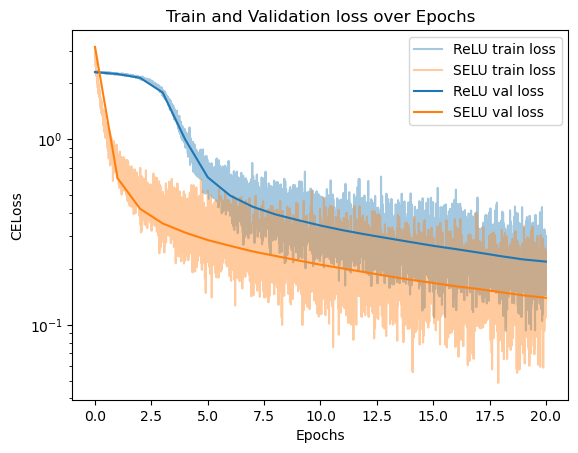

In [11]:
plt.figure()
plt.plot(np.asarray(range(len(rtl))) / len(trainloader), rtl, alpha=0.4, label="ReLU train loss")
plt.plot(np.asarray(range(len(stl))) / len(trainloader), stl, alpha=0.4, label="SELU train loss")
plt.plot(range(len(rvl)), rvl, color="C0", label="ReLU val loss")
plt.plot(range(len(svl)), svl, color="C1", label="SELU val loss")
plt.title("Train and Validation loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("CELoss")
plt.yscale("log")

plt.legend()
plt.show()

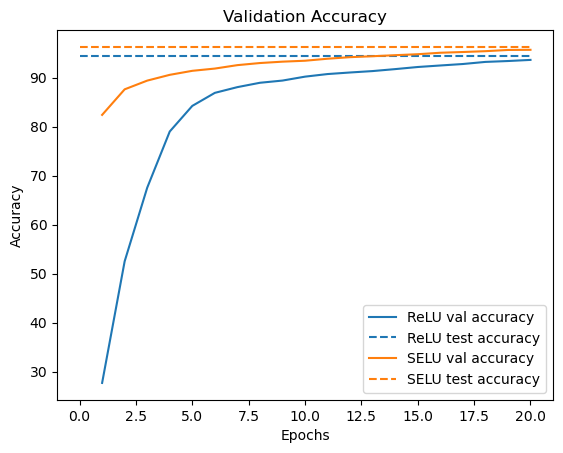

In [12]:
plt.figure()
plt.plot(range(1, len(raccs)+1), [a*100 for a in raccs], label="ReLU val accuracy")
plt.hlines(y=racc*100, xmin=0, xmax=len(raccs), colors="C0", linestyles="dashed", label="ReLU test accuracy")
plt.plot(range(1, len(saccs)+1), [a*100 for a in saccs], label="SELU val accuracy")
plt.hlines(y=sacc*100, xmin=0, xmax=len(saccs), colors="C1", linestyles="dashed", label="SELU test accuracy")
plt.title("Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()
plt.show()